In [1]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


# Import torch
import torch
import torch.nn as nn
import torch.nn.functional as F

# import lightning
import lightning as L
from lightning.pytorch.loggers import CSVLogger
import torchmetrics

# import Pytorch Geometric
import torch_geometric
import torch_geometric.nn as geom_nn
import torch_geometric.data as geom_data

# Seed
L.seed_everything(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

ModuleNotFoundError: No module named 'pandas'

In [29]:
%reload_ext watermark
%watermark -a "Rodrigo W Pisaia" --iversions --python
torch.cuda.empty_cache()
!nvidia-smi

Author: Rodrigo W Pisaia

Python implementation: CPython
Python version       : 3.10.14
IPython version      : 8.20.0

torchmetrics   : 1.1.2
seaborn        : 0.12.2
torch          : 2.3.0+cu121
pandas         : 2.2.1
numpy          : 1.26.3
lightning      : 2.0.9.post0
torch_geometric: 2.5.3
matplotlib     : 3.8.4

Thu Jul 11 09:17:56 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.99                 Driver Version: 555.99         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0 

## Experimentos em estruturas de grafos

As tarefas em dados estruturados em grafos podem ser agrupadas em três grupos: nível de nó, nível de aresta e nível de grafo.
Os diferentes níveis descrevem em qual nível queremos realizar a classificação/regressão.
Discutiremos todos os três tipos em mais detalhes abaixo.

### Tarefas a nível de nó: Classificação semi-supervisionada de nós

Tarefas a nível de nó têm o objetivo de classificar nós em um grafo.
Normalmente, temos um único grafo grande com mais de 1000 nós, dos quais uma certa quantidade de nós está rotulada.
Aprendemos a classificar esses exemplos rotulados durante o treinamento e tentamos generalizar para os nós não rotulados.

Um exemplo popular que usaremos neste tutorial é o conjunto de dados Cora, uma rede de citações entre artigos.
O Cora consiste em 2708 publicações científicas com links entre si, representando a citação de um artigo por outro.
A tarefa é classificar cada publicação em uma das sete classes.
Cada publicação é representada por um vetor de saco de palavras (bag-of-words).
Isso significa que temos um vetor de 1433 elementos para cada publicação, onde um 1 na característica $i$ indica
que a $i$-ésima palavra de um dicionário pré-definido está no artigo.
Representações binárias de saco de palavras são comumente usadas quando precisamos de codificações muito simples
e já temos uma intuição sobre quais palavras esperar em uma rede.
Existem abordagens muito melhores, mas deixaremos isso para os cursos de PLN discutirem.

Vamos carregar o conjunto de dados abaixo:

> classes
* 0 : Case_Based
* 1 : Genetic_Algorithms
* 2 : Neural_Networks
* 3 : Probabilistic_Methods
* 4 : Reinforcement_Learning
* 5 : Rule_Learning
* 6 : Theory2

In [30]:
DATASET_PATH = os.environ.get("PATH_DATASETS", "data/")
cora_dataset = cora_dataset = torch_geometric.datasets.Planetoid(root=DATASET_PATH, name="Cora")

In [31]:
print(cora_dataset)
cora_dataset.__dict__

Cora()


{'name': 'Cora',
 'split': 'public',
 'root': 'data',
 'transform': None,
 'pre_transform': None,
 'pre_filter': None,
 'log': True,
 '_indices': None,
 'force_reload': False,
 '_data': Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708]),
 'slices': None,
 '_data_list': None}

In [32]:
# the dataset jave 2708 nodes, 5429 (10556/2) edges, 1433 features. 
# this edge values are the double of the real edges because the graph is undirected, 
# if we have a edge from A to B, we also have a edge from B to A
cora_dataset[0]

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

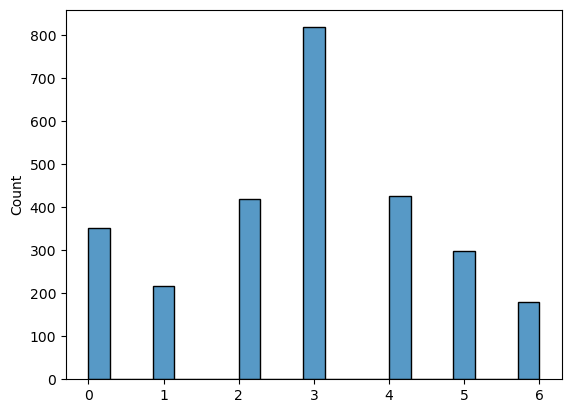

In [33]:
# class distributions
sns.histplot(np.array(cora_dataset[0].y))

In [34]:
gnn_layer_by_name = {
    "GCN": geom_nn.GCNConv,
    "GAT": geom_nn.GATConv,
    "GraphConv": geom_nn.GraphConv,
}

In [35]:
class GNNModel(nn.Module):
    def __init__(
        self,
        c_in,
        c_hidden,
        c_out,
        num_layers=2,
        layer_name="GCN",
        dp_rate=0.1,
        **kwargs
    ):
        """
        Initializes a GNNModel object.

        Args:
            c_in (int): The number of input channels.
            c_hidden (int): The number of hidden channels.
            c_out (int): The number of output channels.
            num_layers (int, optional): The number of GNN layers. Defaults to 2.
            layer_name (str, optional): The name of the GNN layer. Defaults to "GCN".
            dp_rate (float, optional): The dropout rate. Defaults to 0.1.
            **kwargs: Additional keyword arguments to be passed to the GNN layer.

        Returns:
            None
        """
        super().__init__()
        gnn_layer = gnn_layer_by_name[layer_name]
        layers = []

        in_channels, out_channels = c_in, c_out
        for l_idx in range(num_layers - 1):
            layers += [
                gnn_layer(in_channels, c_hidden, *kwargs),
                nn.ReLU(inplace=True),
                nn.Dropout(dp_rate),
            ]
            in_channels = c_hidden
        layers += [gnn_layer(in_channels=in_channels, out_channels=c_out, **kwargs)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x, edge_index):
        """Forward pass of the model.

        Args:
            x (torch.Tensor): Input tensor.
            edge_index (torch.Tensor): Edge index tensor.

        Returns:
            torch.Tensor: Output tensor.
        """
        # Se a camada atual é uma camada de passagem de mensagem,
        # então ela precisa de duas informações para realizar sua operação (x, edge_index)

        # Se a camada atual não é uma camada de passagem de mensagem, por exemplo ReLU. dropout
        # então ela só precisa da entrada x para realizar sua operação.

        for layer in self.layers:
            if isinstance(layer, geom_nn.MessagePassing):
                x = layer(x=x, edge_index=edge_index)
            else:
                x = layer(x)

        return x

In [36]:
geom_nn.MessagePassing

torch_geometric.nn.conv.message_passing.MessagePassing

In [ ]:
class MLPModel(nn.Module):
    def __init__(self, c_in, c_hidden, c_out, num_layers, dp_rate=0.1):
        super().__init__()
        layers = []

        in_channels, out_channels = c_in, c_hidden
        for l_idx in range(num_layers - 1):
            layers += [
                nn.Linear(in_channels, out_channels),
                nn.ReLU(inplace=True),
                nn.Dropout(dp_rate),
            ]

            in_channels = c_hidden
        layers += [nn.Linear(in_channels, c_out)]
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

In [ ]:
class NodeLvelGNN(L.LightningModule):
    def __init__(self, model_name, **model_kwargs):
        super().__init__()
        self.save_hyperparameters()

        if model_name == "MLP":
            self.model = MLPModel(**model_kwargs)
        else:
            self.model = GNNModel(**model_kwargs)
        self.loss_module = nn.CrossEntropyLoss()

        self.acc_train = torchmetrics.Accuracy(task="multiclass", num_classes=7)
        self.acc_val = torchmetrics.Accuracy(task="multiclass", num_classes=7)
        self.acc_test = torchmetrics.Accuracy(task="multiclass", num_classes=7)

    def _shared_step(self, data, mode="train"):
        x, edge_index = data.x, data.edge_index
        x = self.model(x, edge_index)

        if mode == "train":
            mask = data.train_mask
        elif mode == "val":
            mask = data.val_mask
        elif mode == "test":
            mask = data.test_mask
        else:
            assert False, f"Unknown mode: {mode}"

        loss = self.loss_module(x[mask], data.y[mask])
        acc = getattr(self, f"acc_{mode}")(x[mask], data.y[mask])
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch, mode="train")
        self.log("train_loss", loss, on_epoch=True, on_step=False)
        self.log("train_acc", acc, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch, mode="val")
        self.log("val_loss", loss)
        self.log("val_acc", acc)

    def test_step(self, batch, batch_idx):
        _, acc = self._shared_step(batch, mode="test")
        self.log("test_acc", acc)

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(
            self.parameters(), lr=0.1, momentum=0.9, weight_decay=2e-3
        )
        return optimizer

In [39]:
# callbacks
import lightning as L
## modelCheckpoint
ModelCheckpoint = L.pytorch.callbacks.ModelCheckpoint(monitor="val_loss", mode="max", save_top_k=3)
## earlystopping
early_stopping_callback = L.pytorch.callbacks.early_stopping.EarlyStopping(monitor="val_loss", patience=25)


## csv Logger
csv_logger = CSVLogger("logs", name="cora_logs")
node_dataloader = geom_data.DataLoader(cora_dataset, batch_size=1)
trainer = L.Trainer(
    callbacks=[ModelCheckpoint, early_stopping_callback],
    logger=csv_logger,
    accelerator="auto",
    max_epochs=200,
    precision="bf16-mixed",
)

c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [40]:
model = NodeLvelGNN(model_name="GCN", c_in=1433, c_hidden=16, c_out=7, num_layers=2, layer_name="GCN", dp_rate=0.1)
# model.compile() # discomment if you are using unix OS
model

# model = MLPModel(c_in=1433, c_hidden=16, c_out=7, num_layers=2, dp_rate=0.1)

NodeLvelGNN(
  (model): GNNModel(
    (layers): ModuleList(
      (0): GCNConv(1433, 16)
      (1): ReLU(inplace=True)
      (2): Dropout(p=0.1, inplace=False)
      (3): GCNConv(16, 7)
    )
  )
  (loss_module): CrossEntropyLoss()
  (acc_train): MulticlassAccuracy()
  (acc_val): MulticlassAccuracy()
  (acc_test): MulticlassAccuracy()
)

In [41]:
trainer.fit(model, node_dataloader, node_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type               | Params
---------------------------------------------------
0 | model       | GNNModel           | 23.1 K
1 | loss_module | CrossEntropyLoss   | 0     
2 | acc_train   | MulticlassAccuracy | 0     
3 | acc_val     | MulticlassAccuracy | 0     
4 | acc_test    | MulticlassAccuracy | 0     
---------------------------------------------------
23.1 K    Trainable params
0         Non-trainable params
23.1 K    Total params
0.092     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:442: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:442: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\lightning\pytorch\loops\fit_loop.py:281: PossibleUserWarning: The number of training batches

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

In [42]:
test_result = trainer.test(model, dataloaders=node_dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:442: PossibleUserWarning: The dataloader, test_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 16 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Testing: 0it [00:00, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8119999766349792     │
└───────────────────────────┴───────────────────────────┘

In [43]:
def plot_loss_and_acc(
    log_dir, loss_ylim=(0.0, 0.9), acc_ylim=(0.7, 1.0), save_loss=None, save_acc=None
):

    metrics = pd.read_csv(f"{log_dir}/metrics.csv")

    aggreg_metrics = []
    agg_col = "epoch"
    for i, dfg in metrics.groupby(agg_col):
        agg = dict(dfg.mean())
        agg[agg_col] = i
        aggreg_metrics.append(agg)

    df_metrics = pd.DataFrame(aggreg_metrics)
    df_metrics[["train_loss", "val_loss"]].plot(
        grid=True, legend=True, xlabel="Epoch", ylabel="Loss"
    )

    plt.ylim(loss_ylim)
    if save_loss is not None:
        plt.savefig(save_loss)

    df_metrics[["train_acc","val_acc"]].plot(
        grid=True, legend=True, xlabel="Epoch", ylabel="ACC"
    )

    plt.ylim(acc_ylim)
    if save_acc is not None:
        plt.savefig(save_acc)


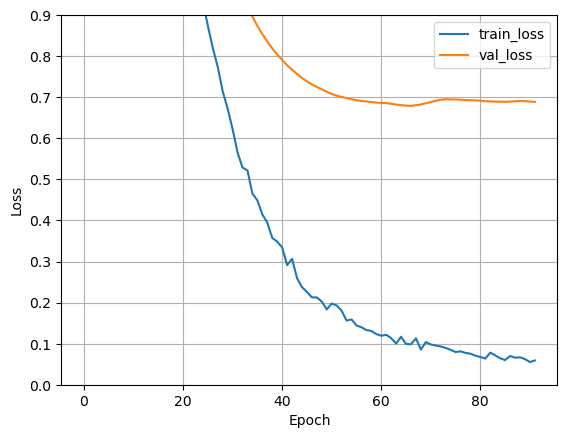

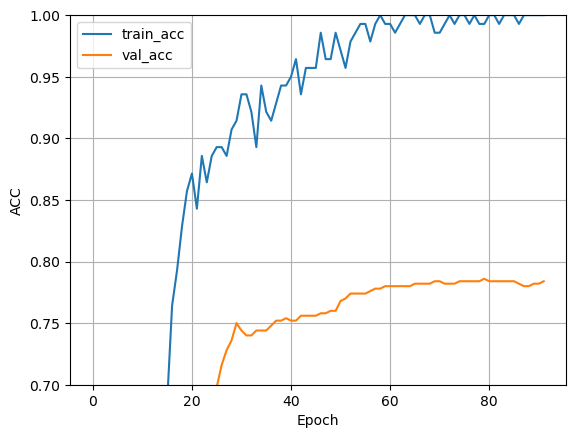

In [44]:
plot_loss_and_acc("logs/cora_logs/version_12", save_loss="loss.png", save_acc="acc.png")

---
---
# Edge-level tasks: link prediction
---
---

### Edge-level tasks: Link prediction

Em algumas aplicações, podemos ter que prever em um nível de aresta em vez de nível de nó. A tarefa mais comum em nível de aresta no GNN é a previsão de link. Previsão de link significa que, dado um grafo, queremos prever se haverá/deverá haver uma aresta entre dois nós ou não. Por exemplo, em uma rede social, isso é usado pelo Facebook e companhia para propor novos amigos para você. Novamente, as informações em nível de gráfico podem ser cruciais para realizar esta tarefa. A previsão de saída geralmente é feita realizando uma métrica de similaridade no par de características do nó, que deve ser 1 se houver um link, e caso contrário, próximo de 0. Para manter o tutorial curto, não implementaremos essa tarefa nós mesmos. No entanto, existem muitos bons recursos por aí se você estiver interessado em olhar mais de perto para esta tarefa. Tutoriais e artigos para este tópico incluem:

* [PyTorch Geometric example](https://github.com/rusty1s/pytorch_geometric/blob/master/examples/link_pred.py)
* [Graph Neural Networks: A Review of Methods and Applications](https://arxiv.org/pdf/1812.08434.pdf), Zhou et al.
2019
* [Link Prediction Based on Graph Neural Networks](https://papers.nips.cc/paper/2018/file/53f0d7c537d99b3824f0f99d62ea2428-Paper.pdf), Zhang and Chen, 2018.

---
---
# Graph-level tasks: Graph classification
---
---

### Graph-level tasks: Graph classification

Finalmente, nesta parte do tutorial, vamos examinar mais de perto como aplicar GNNs à tarefa de classificação de grafos. O objetivo é classificar um grafo inteiro em vez de nós ou arestas individuais. Portanto, também recebemos um conjunto de dados de vários grafos que precisamos classificar com base em algumas propriedades estruturais do grafo. A tarefa mais comum para a classificação de grafos é a previsão de propriedades moleculares, na qual as moléculas são representadas como grafos. Cada átomo está ligado a um nó, e as arestas no grafo são as ligações entre os átomos. Por exemplo, veja a figura abaixo.

<center width="100%"><img src="https://github.com/Lightning-AI/lightning-tutorials/raw/main/course_UvA-DL/06-graph-neural-networks/molecule_graph.svg" width="600px"></center>

À esquerda, temos uma molécula pequena e arbitrária com diferentes átomos, enquanto a parte direita da imagem mostra a representação do grafo. Os tipos de átomos são abstraídos como características dos nós (por exemplo, um vetor one-hot), e os diferentes tipos de ligações são usados como características das arestas. Para simplificar, vamos negligenciar os atributos das arestas neste tutorial, mas você pode incluí-los usando métodos como a [Convolução de Grafo Relacional](https://arxiv.org/abs/1703.06103) que usa uma matriz de pesos diferente para cada tipo de aresta.

O conjunto de dados que usaremos abaixo é chamado de conjunto de dados MUTAG. É um pequeno benchmark comum para algoritmos de classificação de grafos e contém 188 grafos com 18 nós e 20 arestas em média para cada grafo. Os nós do grafo têm 7 rótulos diferentes/tipos de átomos, e os rótulos binários do grafo representam "seu efeito mutagênico em uma bactéria gram-negativa específica" (o significado específico dos rótulos não é muito importante aqui). O conjunto de dados faz parte de uma grande coleção de diferentes conjuntos de dados de classificação de grafos, conhecidos como [TUDatasets](https://chrsmrrs.github.io/datasets/), que é acessível diretamente via `torch_geometric.datasets.TUDataset` ([documentação](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.TUDataset)) no PyTorch Geometric. Podemos carregar o conjunto de dados abaixo.

In [45]:
tu_dataset = torch_geometric.datasets.TUDataset(root=DATASET_PATH, name="MUTAG")
tu_dataset.__dict__

{'name': 'MUTAG',
 'cleaned': False,
 'root': 'data',
 'transform': None,
 'pre_transform': None,
 'pre_filter': None,
 'log': True,
 '_indices': None,
 'force_reload': False,
 '_data': Data(x=[3371, 7], edge_index=[2, 7442], edge_attr=[7442, 4], y=[188]),
 'slices': {'edge_index': tensor([   0,   38,   66,   94,  138,  160,  222,  256,  300,  326,  364,  402,
           448,  498,  526,  570,  620,  642,  680,  708,  748,  786,  824,  878,
           944,  982, 1008, 1062, 1100, 1150, 1204, 1254, 1304, 1354, 1382, 1420,
          1450, 1486, 1518, 1550, 1578, 1616, 1644, 1688, 1726, 1750, 1804, 1854,
          1892, 1936, 1970, 2030, 2090, 2132, 2174, 2204, 2242, 2286, 2344, 2398,
          2438, 2476, 2498, 2546, 2590, 2624, 2658, 2704, 2758, 2800, 2830, 2890,
          2926, 2960, 3014, 3052, 3072, 3106, 3140, 3178, 3222, 3246, 3302, 3338,
          3360, 3414, 3468, 3504, 3528, 3556, 3610, 3668, 3712, 3766, 3810, 3850,
          3906, 3946, 3974, 4008, 4042, 4096, 4152, 4196, 4250,

In [46]:
print("Data object:", tu_dataset.data)
print("Length:", len(tu_dataset))
print("Average label: %4.2f" % (tu_dataset.data.y.float().mean().item()))

Data object: Data(x=[3371, 7], edge_index=[2, 7442], edge_attr=[7442, 4], y=[188])
Length: 188
Average label: 0.66


c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\torch_geometric\data\in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


In [48]:
len(tu_dataset.data.y)

c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\torch_geometric\data\in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


188

In [26]:
torch.manual_seed(42)
tu_dataset.shuffle()
train_dataset = tu_dataset[:150]
test_dataset = tu_dataset[150:]

In [52]:
### repeating the code
class GNNModel(nn.Module):
    def __init__(
        self,
        c_in,
        c_hidden,
        c_out,
        num_layers=2,
        layer_name="GCN",
        dp_rate=0.1,
        **kwargs
    ):
        """
        Initializes a GNNModel object.

        Args:
            c_in (int): The number of input channels.
            c_hidden (int): The number of hidden channels.
            c_out (int): The number of output channels.
            num_layers (int, optional): The number of GNN layers. Defaults to 2.
            layer_name (str, optional): The name of the GNN layer. Defaults to "GCN".
            dp_rate (float, optional): The dropout rate. Defaults to 0.1.
            **kwargs: Additional keyword arguments to be passed to the GNN layer.

        Returns:
            None
        """
        super().__init__()
        gnn_layer = gnn_layer_by_name[layer_name]
        layers = []

        in_channels, out_channels = c_in, c_out
        for l_idx in range(num_layers - 1):
            layers += [
                gnn_layer(in_channels, c_hidden, *kwargs),
                nn.ReLU(inplace=True),
                nn.Dropout(dp_rate),
            ]
            in_channels = c_hidden
        layers += [gnn_layer(in_channels=in_channels, out_channels=c_out, **kwargs)]
        self.layers = nn.ModuleList(layers)

    def forward(self, x, edge_index):
        """Forward pass of the model.

        Args:
            x (torch.Tensor): Input tensor.
            edge_index (torch.Tensor): Edge index tensor.

        Returns:
            torch.Tensor: Output tensor.
        """
        # Se a camada atual é uma camada de passagem de mensagem,
        # então ela precisa de duas informações para realizar sua operação (x, edge_index)

        # Se a camada atual não é uma camada de passagem de mensagem, por exemplo ReLU. dropout
        # então ela só precisa da entrada x para realizar sua operação.

        for layer in self.layers:
            if isinstance(layer, geom_nn.MessagePassing):
                x = layer(x=x, edge_index=edge_index)
            else:
                x = layer(x)

        return x

In [58]:
# creating the model
class GraphGNNModel(nn.Module):
    def __init__(self, c_in, c_hidden, c_out, dp_rate_linear=0.5, **kwargs):
        """
        Initialize the GNNModel class.

        Args:
            c_in (int): The number of input features.
            c_hidden (int): The number of hidden features.
            c_out (int): The number of output features.
            dp_rate_linear (float, optional): Dropout rate for linear layer. Defaults to 0.5.
            **kwargs: Additional keyword arguments to be passed to the GNNModel constructor.
        """
        super().__init__()
        self.GNN = GNNModel(c_in=c_in, c_hidden=c_hidden, c_out=c_out, **kwargs)
        self.head = nn.Sequential(
            nn.Dropout(dp_rate_linear), nn.Linear(c_hidden, c_out)
        )

    def forward(self, x, edge_index, batch_index):
        x = self.GNN(x, edge_index)
        x = geom_nn.global_mean_pool(x, batch_index)
        return self.head(x)

In [59]:
class GraphLevelGNN(L.LightningModule):
    def __init__(self, **kwargs):
        super().__init__()
        self.save_hyperparameters()

        self.model = GraphGNNModel(**kwargs)
        self.loss_module = (
            nn.BCEWithLogitsLoss() if self.hparams.c_out == 1 else nn.CrossEntropyLoss()
        )

    def forward(self, data, mode="train"):
        x, edge_index, batch_index = data.x, data.edge_index, data.batch
        x = self.model(x, edge_index, batch_index)
        x = x.squeeze(dim=-1)

        if self.hparams.c_out == 1:
            preds = (x > 0).float()
            data.y = data.y.float()
        else:
            preds = x.argmax(dim=-1)
        loss = self.loss_module(x, data.y)
        acc = torchmetrics.functional.accuracy(preds, data.y)
        return loss, acc

    def configure_optimizers(self):
        # High lr because of small dataset and small model
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-2, weight_decay=0.0)
        return optimizer

    def training_step(self, batch, batch_idx):
        loss, acc = self.forward(batch, mode="train")
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self.forward(batch, mode="val")
        self.log("val_loss", loss, on_step=False, on_epoch=True)
        self.log("val_acc", acc, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        _, acc = self.forward(batch, mode="test")
        self.log("test_acc", acc)

In [60]:
def train_graph_classifier(model_name, **model_kwargs):
    L.seed_everything(42)

    # Create a PyTorch Lightning trainer with the generation callback
    root_dir = os.path.join(CHECKPOINT_PATH, "GraphLevel" + model_name)
    os.makedirs(root_dir, exist_ok=True)
    trainer = L.Trainer(
        default_root_dir=root_dir,
        callbacks=[
            ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc")
        ],
        accelerator="cuda",
        devices=AVAIL_GPUS,
        max_epochs=500,
        enable_progress_bar=False,
    )
    trainer.logger._default_hp_metric = None

    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(
        CHECKPOINT_PATH, "GraphLevel%s.ckpt" % model_name
    )
    if os.path.isfile(pretrained_filename):
        print("Found pretrained model, loading...")
        model = GraphLevelGNN.load_from_checkpoint(pretrained_filename)
    else:
        L.seed_everything(42)
        model = GraphLevelGNN(
            c_in=tu_dataset.num_node_features,
            c_out=1 if tu_dataset.num_classes == 2 else tu_dataset.num_classes,
            **model_kwargs,
        )
        trainer.fit(model, graph_train_loader, graph_val_loader)
        model = GraphLevelGNN.load_from_checkpoint(
            trainer.checkpoint_callback.best_model_path
        )

    # Test best model on validation and test set
    train_result = trainer.test(model, dataloaders=graph_train_loader, verbose=False)
    test_result = trainer.test(model, dataloaders=graph_test_loader, verbose=False)
    result = {"test": test_result[0]["test_acc"], "train": train_result[0]["test_acc"]}
    return model, result

c:\Users\Rodrigo W Pisaia\Anaconda\envs\graph_py310\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [61]:
trainer.fit(GraphLevelGNN(c_in=7, c_hidden=256, c_out=1, dp_rate_linear=0.5), dataloader, dataloader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | model       | GraphGNNModel     | 2.6 K 
1 | loss_module | BCEWithLogitsLoss | 0     
--------------------------------------------------
2.6 K     Trainable params
0         Non-trainable params
2.6 K     Total params
0.010     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x1 and 256x1)